First 5 Rows of Dataset:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Up

C:\Users\adars\AppData\Local\Temp\ipykernel_14796\401689201.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


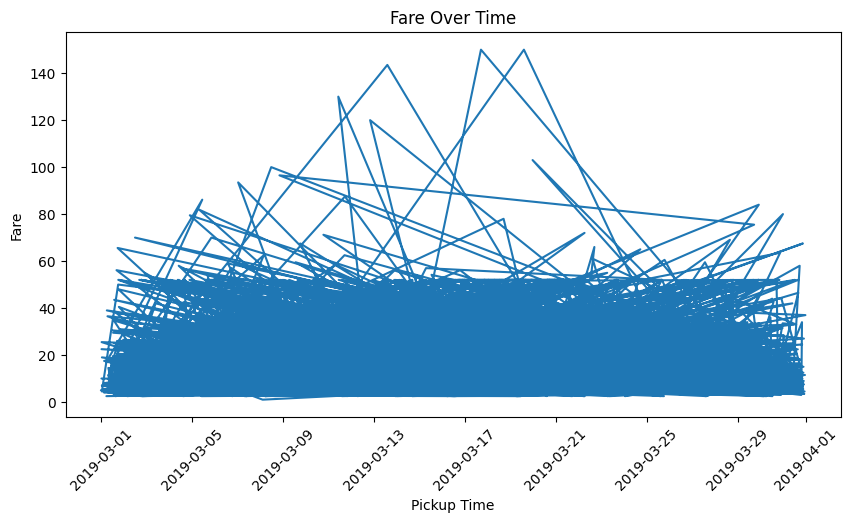

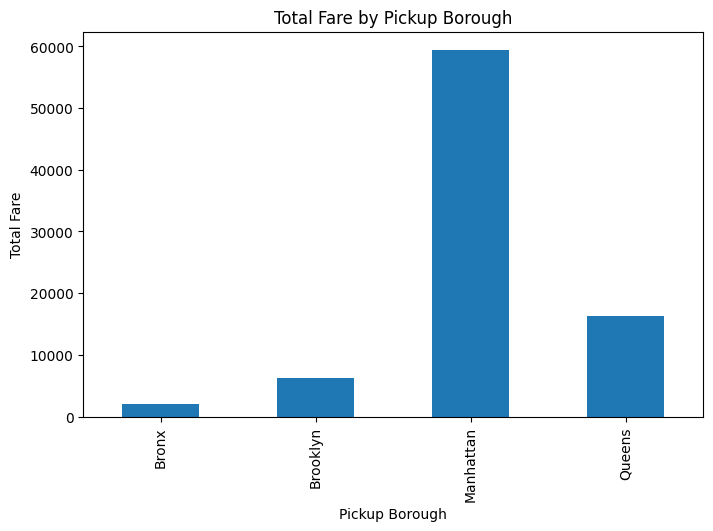

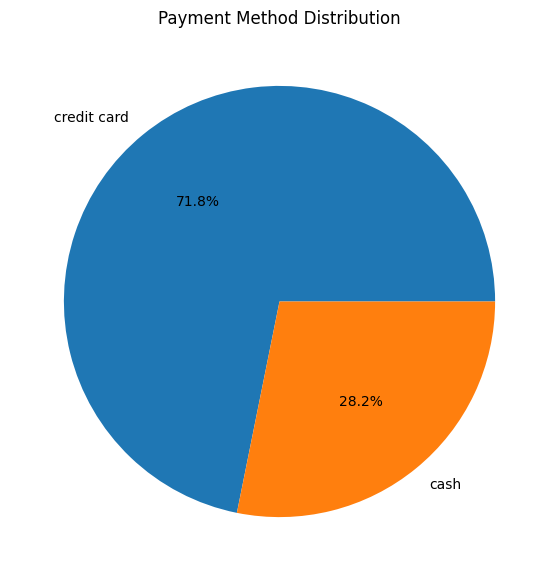

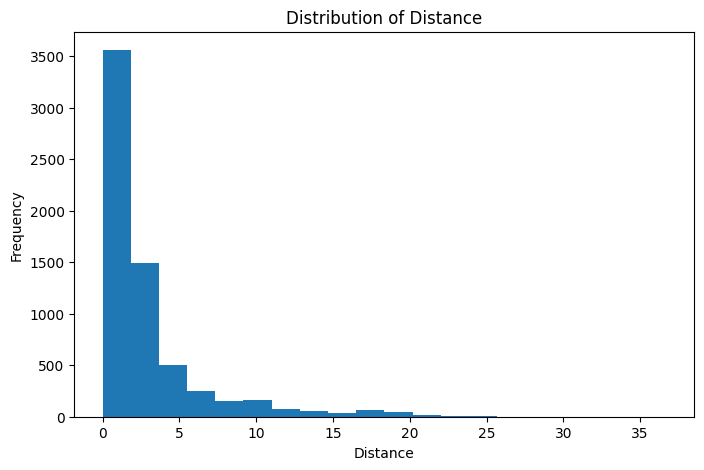

C:\Users\adars\AppData\Local\Temp\ipykernel_14796\401689201.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


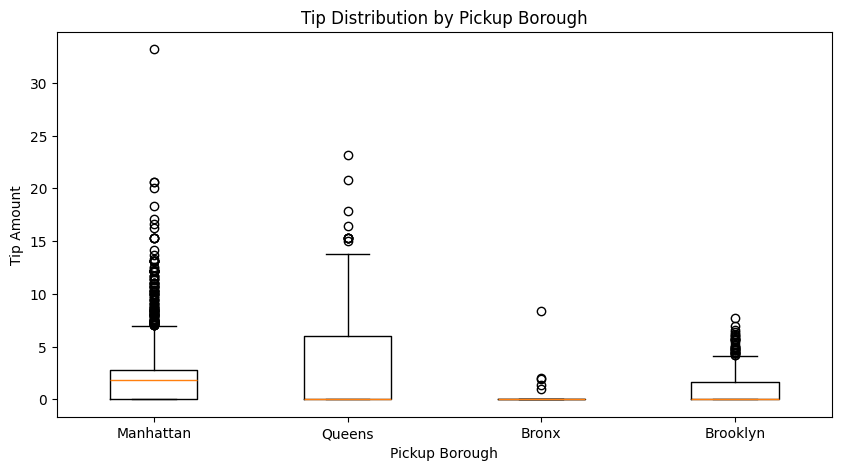

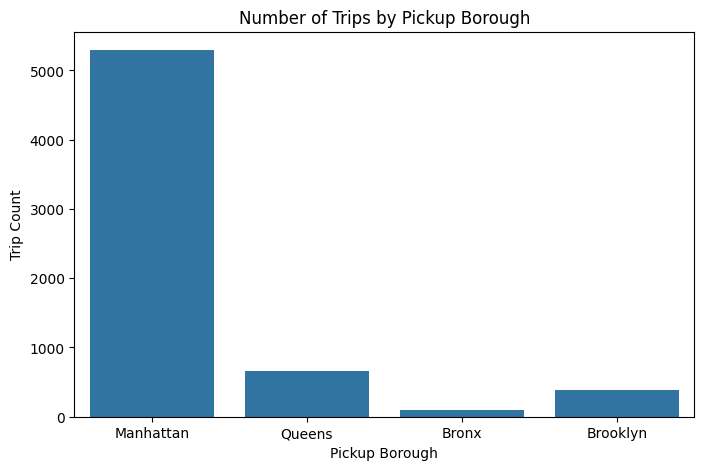

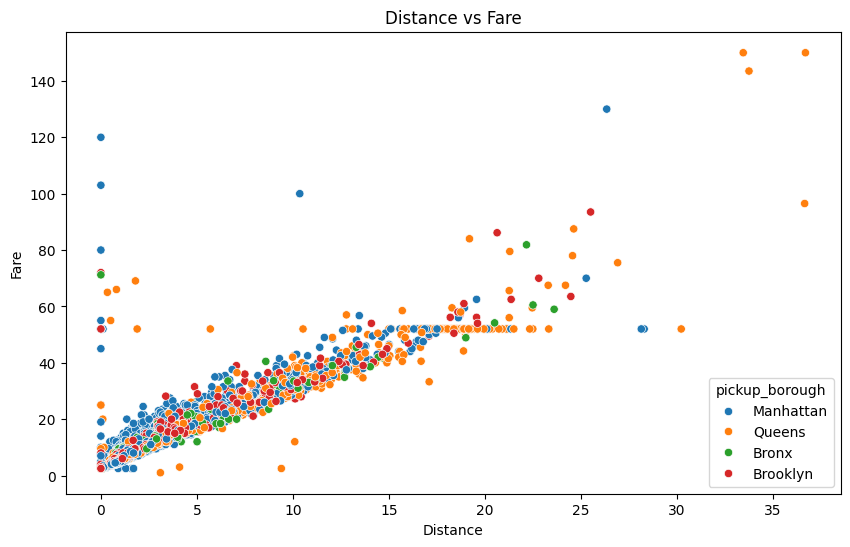

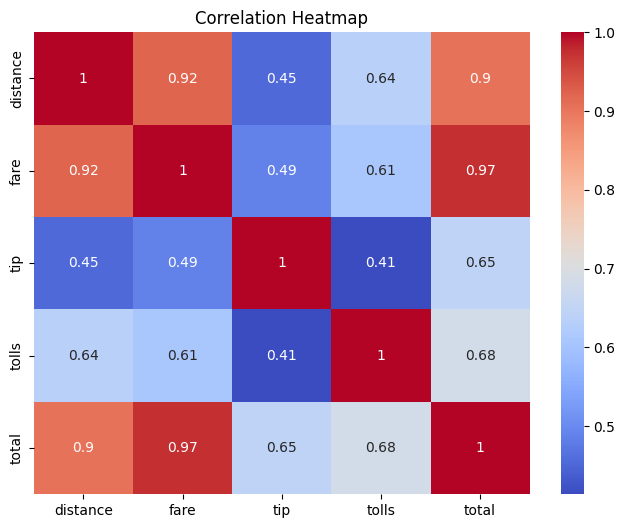

In [ ]:
# =========================================================
# DATA SCIENCE (DS) MODULE - 2
# Python DS Assignment 2 - Data Visualization
# =========================================================

# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# LOAD THE DATASET
# =========================================================

# Load taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# =========================================================
# DATASET INFORMATION
# =========================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

# =========================================================
# CHECK MISSING VALUES
# =========================================================

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

# Numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Fill numerical missing values with median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Fill categorical missing values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Remove remaining missing rows if any
df = df.dropna()

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# =========================================================
# CONVERT PICKUP COLUMN TO DATETIME
# =========================================================

df['pickup'] = pd.to_datetime(df['pickup'])

# =========================================================
# VISUALIZATIONS USING MATPLOTLIB / PANDAS
# =========================================================

# =========================================================
# LINE CHART
# Fare over Time
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(df['pickup'], df['fare'])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# BAR CHART
# Total Fare by Pickup Borough
# =========================================================

borough_fare = df.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(8, 5))

borough_fare.plot(kind='bar')

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.show()

# =========================================================
# PIE CHART
# Payment Method Distribution
# =========================================================

payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")

plt.show()

# =========================================================
# HISTOGRAM
# Distance Distribution
# =========================================================

plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=20)

plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# BOX PLOT
# Tip Amount by Pickup Borough
# =========================================================

plt.figure(figsize=(10, 5))

plt.boxplot(
    [df[df['pickup_borough'] == borough]['tip']
     for borough in df['pickup_borough'].unique()],
    labels=df['pickup_borough'].unique()
)

plt.title("Tip Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")

plt.show()

# VISUALIZATIONS USING SEABORN



# COUNT PLOT
# Trips by Pickup Borough


plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='pickup_borough')

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")

plt.show()

# SCATTER PLOT
# Distance vs Fare


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.title("Distance vs Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.show()

# =========================================================
# HEATMAP
# Correlation Matrix
# =========================================================

# Select numerical columns
corr_columns = ['distance', 'fare', 'tip', 'tolls', 'total']

correlation = df[corr_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# PAIR PLOT
# =========================================================

sns.pairplot(
    df[
        ['distance', 'fare', 'tip', 'total', 'pickup_zone']
    ],
    hue='pickup_zone'
)

plt.show()

# =========================================================
# VIOLIN PLOT
# Fare Distribution by Payment Method
# =========================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.show()


# SUMMARY FINDINGS


print("\n========== SUMMARY FINDINGS ==========")

print("""
1. Missing values were identified and handled successfully.

2. Fare values vary based on pickup borough and trip distance.

3. Most trips were completed using specific payment methods.

4. Distance and fare show a positive relationship.

5. Heatmap indicates correlation among fare, total amount, and tip.

6. Different pickup zones show varying fare and distance patterns.

7. Violin plot helps understand fare distribution across payment methods.
""")

print("========== ASSIGNMENT COMPLETED SUCCESSFULLY ==========")